# BinWaves example in Cantabria (Validation)

**In this notebook**: 
<br><br>
Here waves are reconstructed at the buoy location for comparison.
<br><br>
Steps:
- Buoy is loaded.
- Kp propagation coefficients and hindcast reconstruction is made at the buoy location.
- Comparison plots and statistics are shown.

In [1]:
import pandas as pd
import xarray as xr

# Load buoy data and kps

buoy_waves = pd.read_pickle("outputs/buoy_41025_bulk_parameters.pkl").sort_index().loc["2022"]
kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc").isel(site=[0])
kp_coeffs

<xarray.Dataset> Size: 4MB
Dimensions:   (case_num: 696, site: 1, freq: 31, dir: 24)
Coordinates:
  * case_num  (case_num) int64 6kB 0 1 2 3 4 5 6 ... 689 690 691 692 693 694 695
  * site      (site) int64 8B 1
  * freq      (freq) float64 248B 0.03 0.0329 0.0362 ... 0.4145 0.4552 0.5
  * dir       (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    lat       float64 8B ...
    lon       float64 8B ...
    utm_x     (site) float64 8B ...
    utm_y     (site) float64 8B ...
Data variables:
    kps       (case_num, site, freq, dir) float64 4MB ...

In [2]:
kp_coeffs.utm_x.values, kp_coeffs.utm_y.values

(array([514397.61]), array([4051843.74]))

In [3]:
from utils.operations import transform_ERA5_spectrum
import numpy as np
model_parameters = pd.read_csv("NC_cases/swan_cases.csv").to_dict(orient="list")

# Load interest spectra
offshore_spectra, offshore_spectra_case = (  # Unpack both values from the tuple
    transform_ERA5_spectrum(
        era5_spectrum=xr.open_dataset("outputs/jen_north_carolina_spec_utm_unique.nc"),
        subset_parameters=model_parameters,
        available_case_num=kp_coeffs.case_num.values,
    )
)

# Add coordinates directly to offshore_spectra
# buoy 44088
offshore_spectra_case.coords['longitude'] = np.float32(285.161)
offshore_spectra_case.coords['latitude'] = np.float32(36.6120)
# buoy 44100
# offshore_spectra_case.coords['longitude'] = np.float32(284.407)
# offshore_spectra_case.coords['latitude'] = np.float32(36.2580)
# # buoy 44056
# offshore_spectra_case.coords['longitude'] = np.float32(284.286)
# offshore_spectra_case.coords['latitude'] = np.float32(36.2000)
# # buoy 41120
# offshore_spectra_case.coords['longitude'] = np.float32(284.715)
# offshore_spectra_case.coords['latitude'] = np.float32(35.2580)
# buoy 41025
# offshore_spectra_case.coords['longitude'] = np.float32(284.546)
# offshore_spectra_case.coords['latitude'] = np.float32(35.0100)
# # buoy 44095
# offshore_spectra_case.coords['longitude'] = np.float32(284.67)
# offshore_spectra_case.coords['latitude'] = np.float32(35.7500)
# # buoy 44086
# offshore_spectra_case.coords['longitude'] = np.float32(284.579)
# offshore_spectra_case.coords['latitude'] = np.float32(36.0010)

# Add attributes to the coordinates
offshore_spectra_case.coords['longitude'].attrs = {
    'units': 'degrees_east',
    'long_name': 'Longitude'
}
offshore_spectra_case.coords['latitude'].attrs = {
    'units': 'degrees_north',
    'long_name': 'Latitude'
}
offshore_spectra_case

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/core/accessor_dt.py:163: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  field_values = method(freq=freq).values


<xarray.DataArray 'efth' (case_num: 696, time: 405409)> Size: 1GB
array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 7.0847166e-20,
        7.2790246e-20, 6.9479947e-20],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0095968e-19,
        1.0773933e-19, 1.1075864e-19],
       ...,
       [0.0000000e+00, 3.8440106e-27, 2.4607124e-22, ..., 6.3432267e-12,
        6.6909811e-12, 5.5221825e-12],
       [0.0000000e+00, 2.4330966e-27, 1.5166782e-22, ..., 2.2817579e-12,
        2.6370165e-12, 2.0167759e-12],
       [0.0000000e+00, 4.5172463e-25, 8.0684214e-23, ..., 1.0713248e-12,
        1.1941346e-12, 7.9873337e-13]], shape=(696, 405409), dtype=float32)
Coordinates:
  * case_num   (case_num) int64 6kB 0 1 2 3 4 5 6 ... 690 691 692 693 694 695
    station    int32 4B 133
  * time       (time) datetime64[ns] 3MB 1979-01-01 ... 2025-04-01
    longitude  float32 4B 285.2
    latitude   float32 4B 36.61

In [4]:
# import xarray as xr

# # Load the dataset
# offshore_spectra_case = xr.open_dataset("outputs/jen_north_carolina_spec_utm_unique.nc")


# import numpy as np
# times = offshore_spectra_case.time.to_index()
# unique_times, unique_idx = np.unique(offshore_spectra_case.time.values, return_index=True)
# offshore_spectra_case = offshore_spectra_case.isel(time=unique_idx)
# offshore_spectra_case.to_netcdf("outputs/jen_north_carolina_spec_utm_unique.nc")

In [5]:
from bluemath_tk.waves.binwaves import reconstruc_spectra
# Reconstruct spectra

reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=buoy_waves.index, method="nearest"),
    kp_coeffs=kp_coeffs,
)
reconstructed_onshore_spectra

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 141.65 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.Dataset> Size: 313MB
Dimensions:    (site: 1, freq: 31, dir: 24, time: 52526)
Coordinates:
  * site       (site) int64 8B 1
  * freq       (freq) float64 248B 0.03 0.0329 0.0362 ... 0.4145 0.4552 0.5
  * dir        (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    lat        float64 8B 0.0
    lon        float64 8B 0.0
    utm_x      (site) float64 8B 5.144e+05
    utm_y      (site) float64 8B 4.052e+06
    station    int32 4B 133
  * time       (time) datetime64[ns] 420kB 2022-01-01 2022-01-01 ... 2023-01-01
    longitude  float32 4B 285.2
    latitude   float32 4B 36.61
Data variables:
    kps        (time, site, freq, dir) float64 313MB 0.0 0.0 ... 3.445e-11

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)
/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


ValueError: array must not contain infs or NaNs

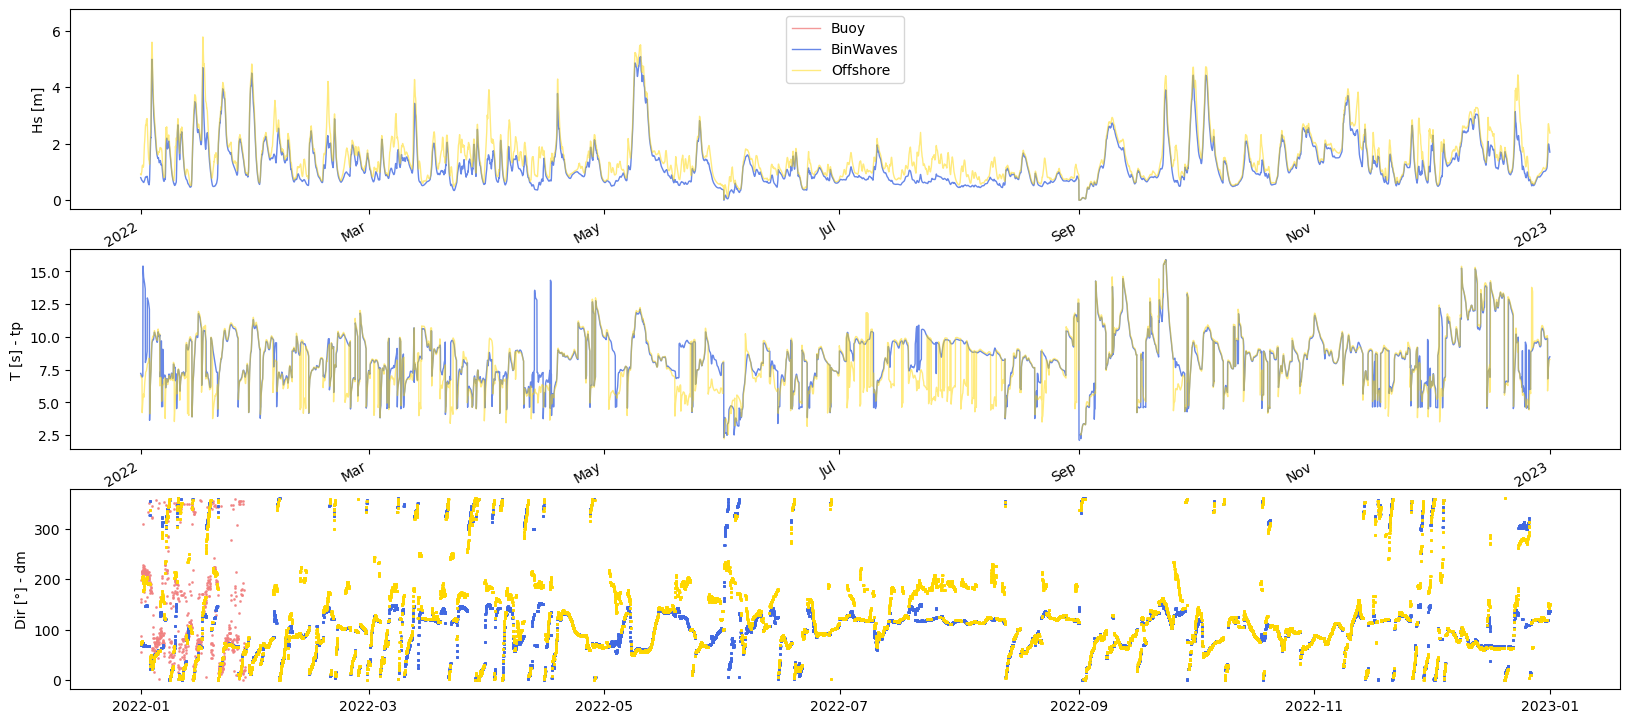

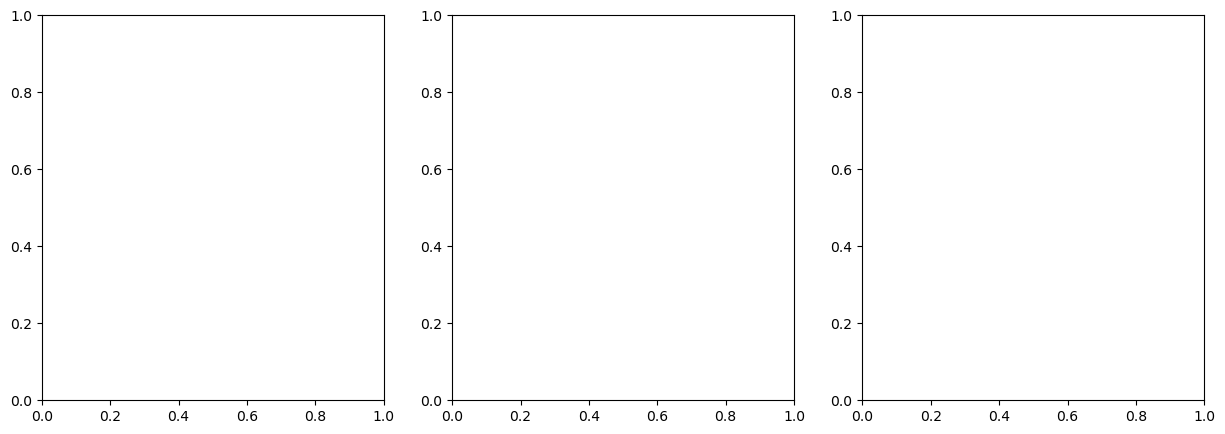

In [6]:
from utils.plotting import plot_wave_series

# Plot reconstructed bulk parameters vs buoy data

# plot_wave_series(
#     buoy_data=buoy_waves,
#     binwaves_data=reconstructed_onshore_spectra.rename({"kps": "efth"})
#     .squeeze()
#     .sel(time=buoy_waves.index, method="nearest")
#     .spec,
#     offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
#     times=buoy_waves.index.values,
# )
# Plot reconstructed bulk parameters vs buoy data
plot_wave_series(
    buoy_data=buoy_waves,
    binwaves_data=reconstructed_onshore_spectra.rename({"kps": "efth"})
    .squeeze()
    .drop_duplicates('time')  # Add this line to remove duplicates
    .sel(time=buoy_waves.index, method="nearest")
    .spec,
    offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
    times=buoy_waves.index.values,
)